In [ ]:
!pip install snowflake pandas sci-kit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 4.6 MB/s eta 0:00:00


In [ ]:
import snowflake.connector
import pandas as pd

In [ ]:
con=snowflake.connector.connect(
    user='Shivaji',
    password='Shivaji11042007',
    account='PLFONYJ-PV16555',
    database='titanic',
    schema="PUBLIC",
    warehouse='COMPUTE_WH'
)


In [ ]:
query='select * from titanicdb'
df=pd.read_sql(query,con)

/tmp/ipykernel_801/2710069945.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,con)


In [ ]:
df


,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,CABIN,EMBARKED
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,None,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,None,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,None,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,None,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,None,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PASSENGERID  891 non-null    int64  
 1   SURVIVED     891 non-null    int64  
 2   PCLASS       891 non-null    int64  
 3   NAME         891 non-null    object 
 4   SEX          891 non-null    object 
 5   AGE          714 non-null    float64
 6   SIBSP        891 non-null    int64  
 7   PARCH        891 non-null    int64  
 8   TICKET       891 non-null    object 
 9   FARE         891 non-null    float64
 10  CABIN        204 non-null    object 
 11  EMBARKED     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().sum()

,0
PASSENGERID,0
SURVIVED,0
PCLASS,0
NAME,0
SEX,0
AGE,177
SIBSP,0
PARCH,0
TICKET,0
FARE,0


In [ ]:
null=['AGE','CABIN']

In [ ]:
df['AGE']=df['AGE'].fillna(df['AGE']).mean()

In [ ]:
df['EMBARKED']=df['EMBARKED'].fillna(df['EMBARKED']).mode()[0]

In [ ]:
df['CABIN']=df['CABIN'].fillna(df['CABIN']).mode()[0]

In [ ]:
df.isnull().sum()

,0
PASSENGERID,0
SURVIVED,0
PCLASS,0
NAME,0
SEX,0
AGE,0
SIBSP,0
PARCH,0
TICKET,0
FARE,0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

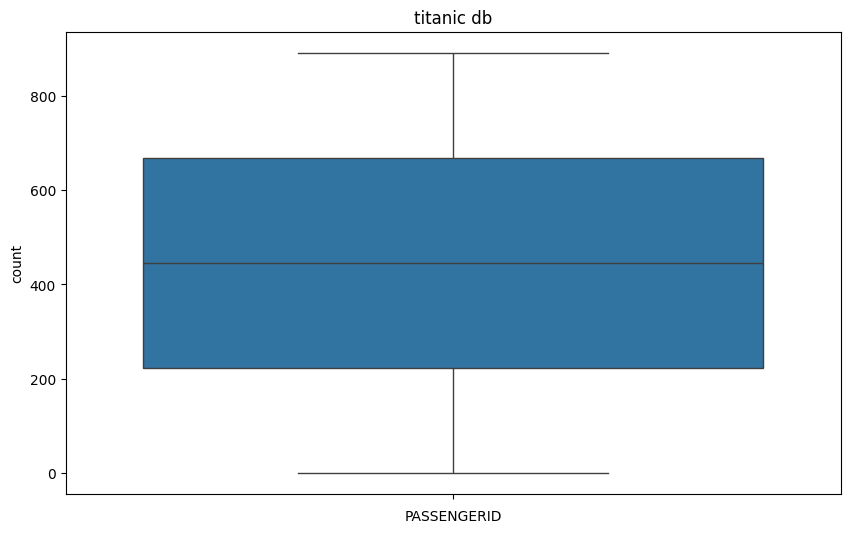

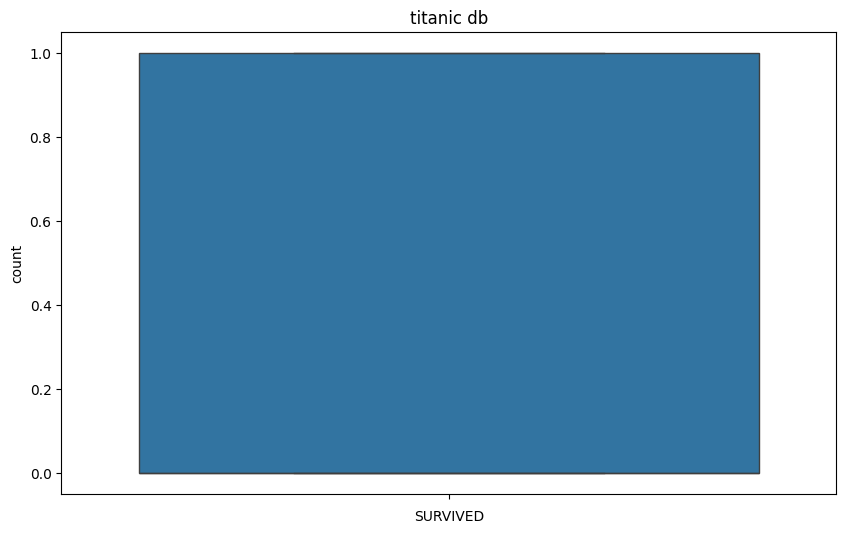

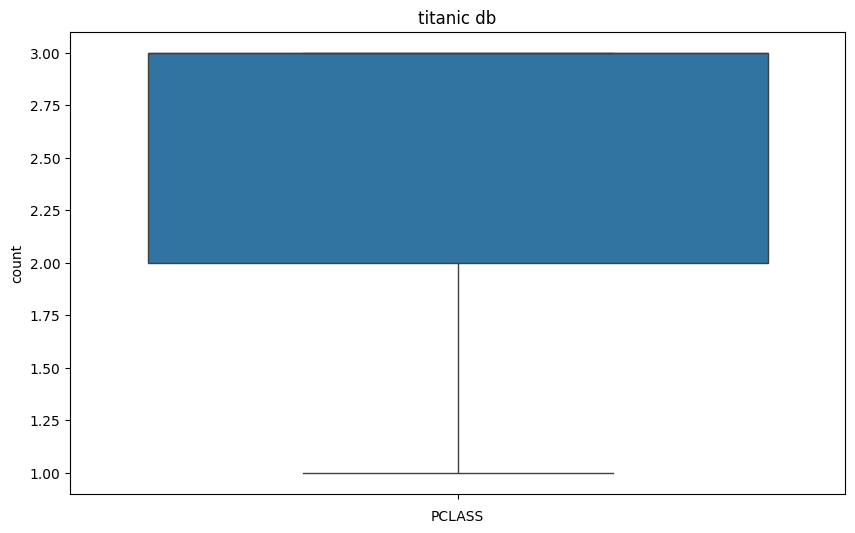

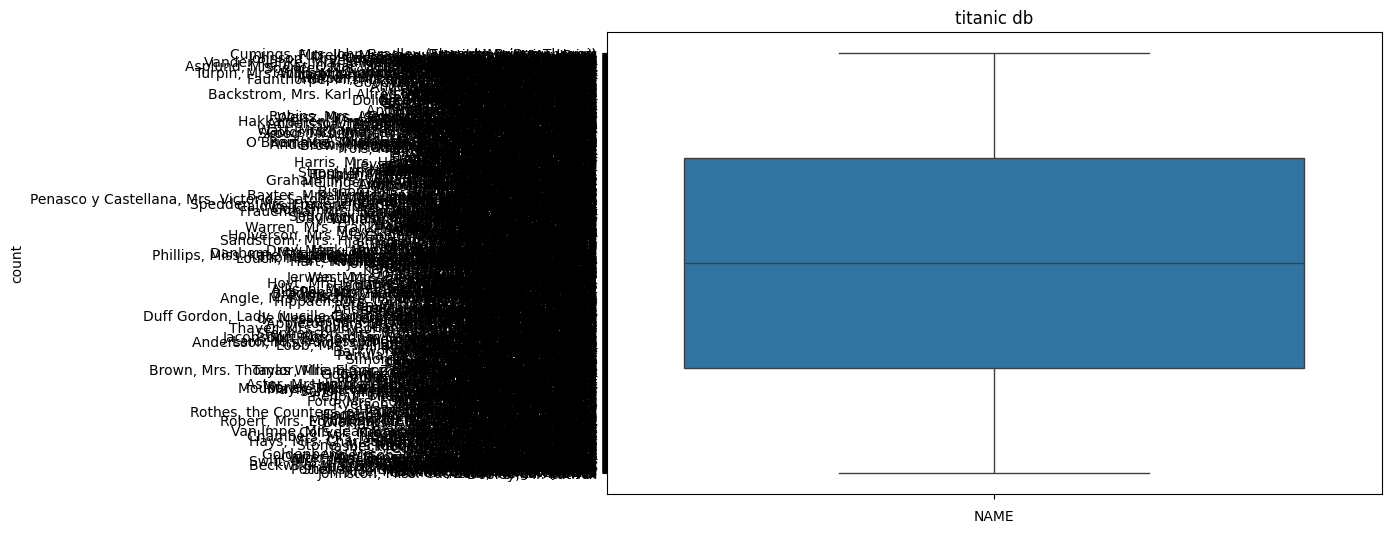

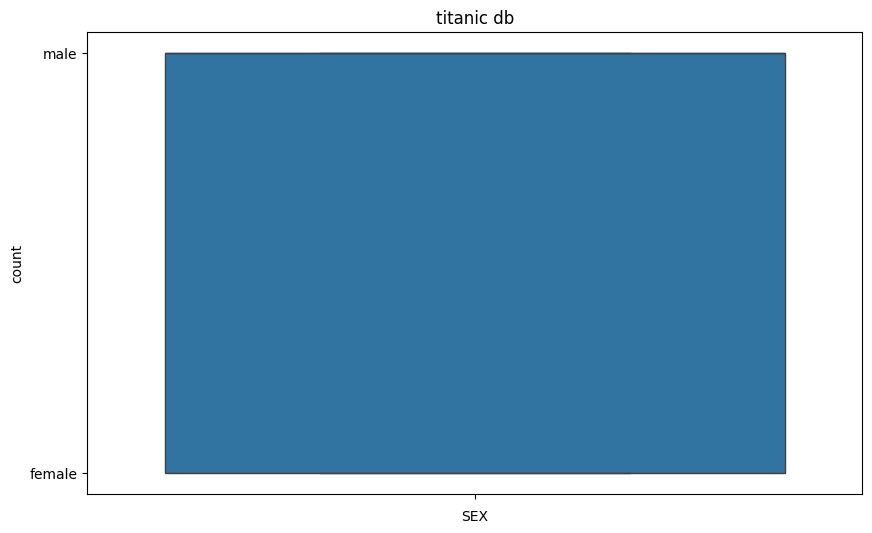

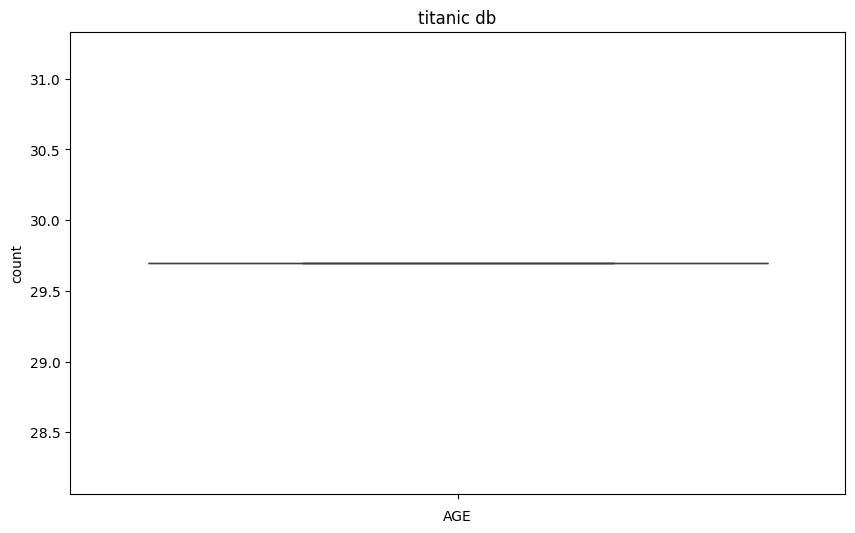

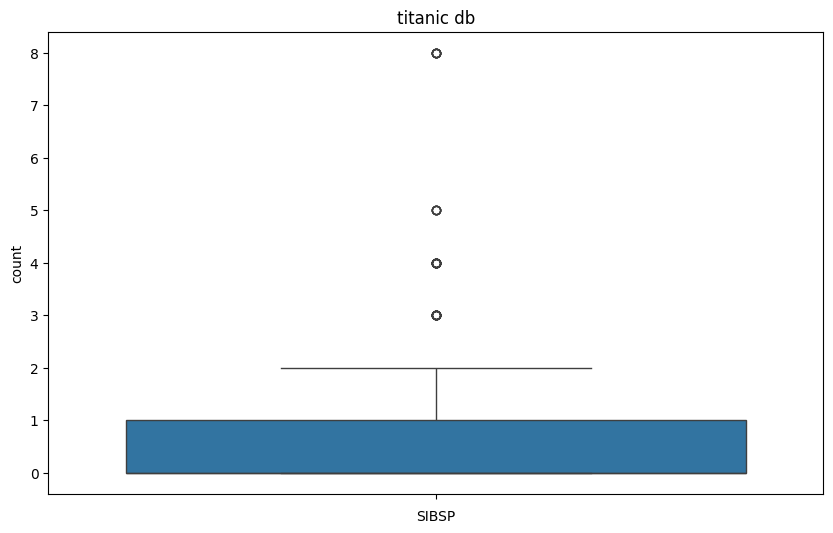

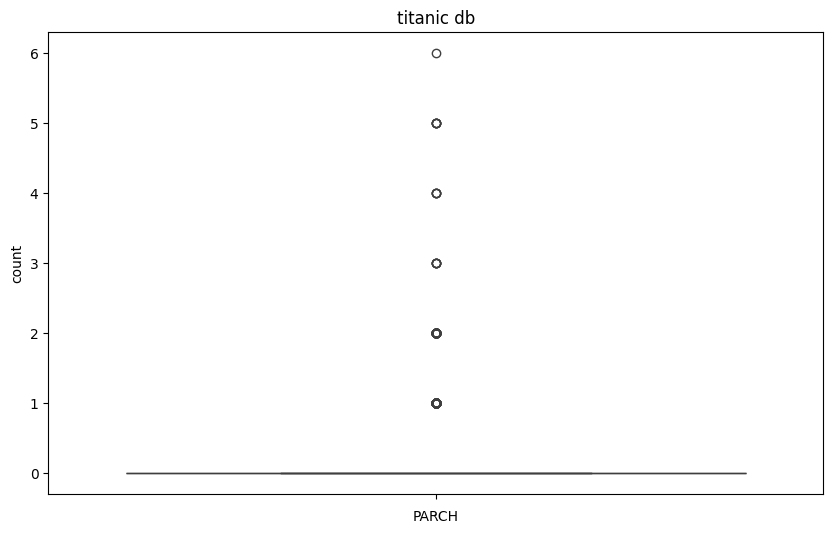

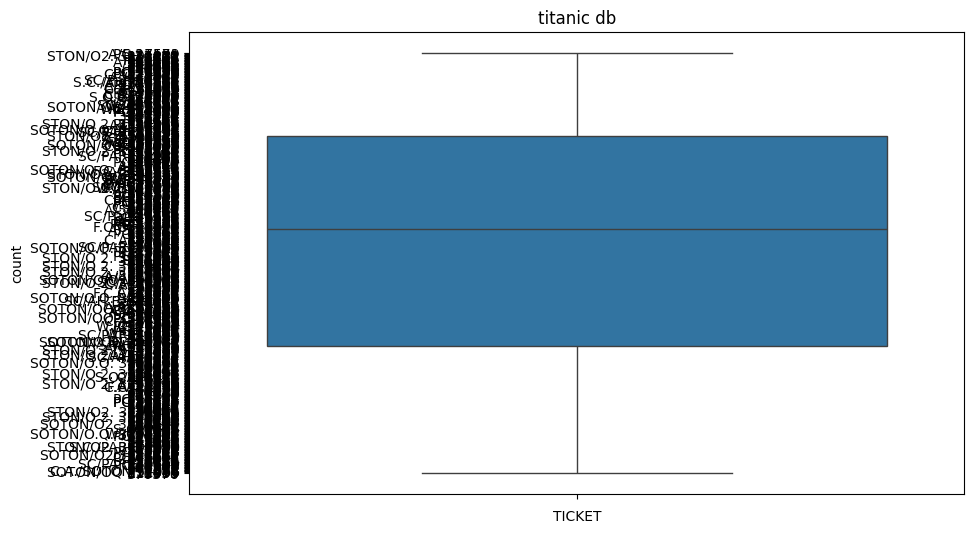

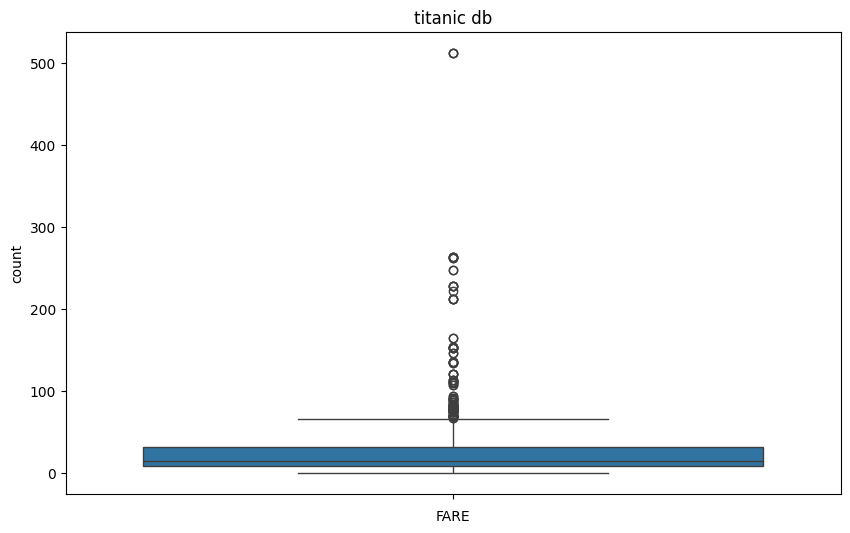

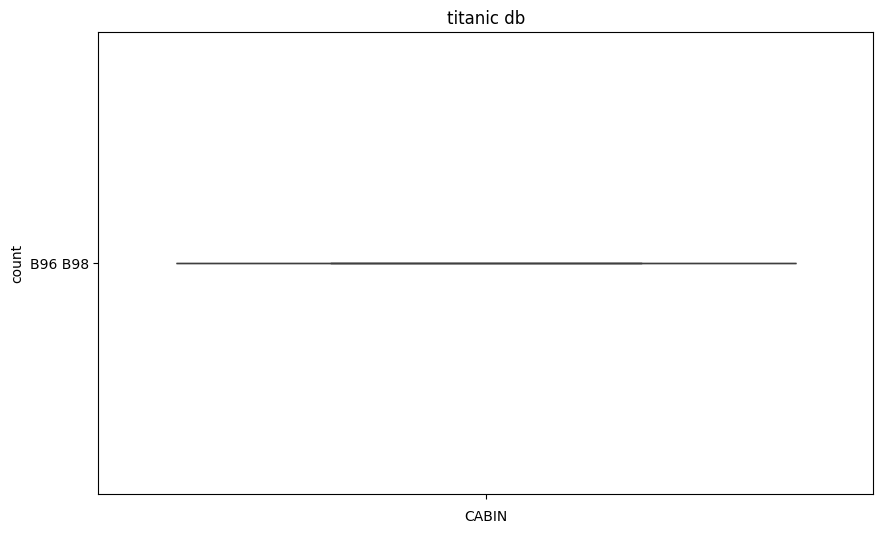

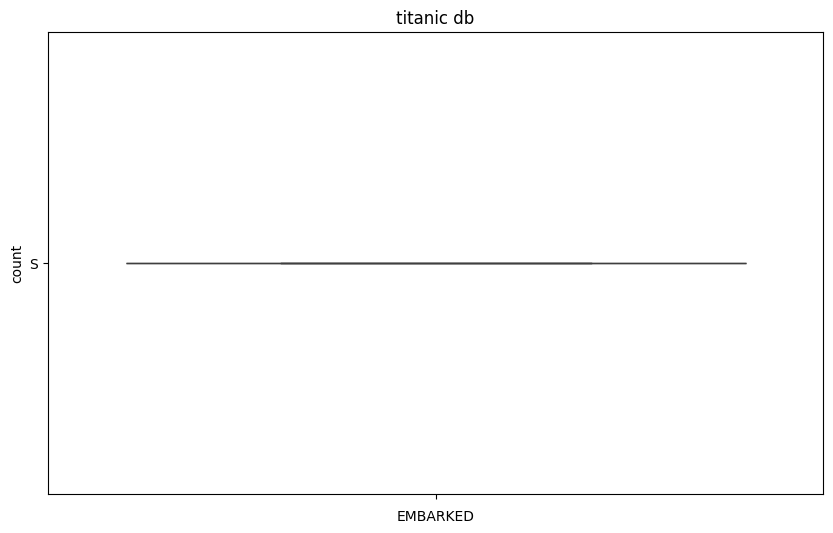

In [ ]:
for i in df.columns:
  if df[i].dtypes != "objects":
    plt.figure(figsize=(10,6))
    sns.boxplot(df[i])
    plt.title("titanic db")
    plt.xlabel(i)
    plt.ylabel("count")
    plt.show()

In [ ]:
out=['SIBSP','PARCH','FARE']

In [ ]:
for i in out:
  Q1=df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR=Q3-Q1

  lb = Q1 - 1.5*IQR
  ub = Q3 + 1.5*IQR

  df=df[(lb<=df[i]) & (ub>=df[i])]


In [ ]:
for i in out:
  Q1=df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR=Q3-Q1

  lb = Q1 - 1.5*IQR
  ub = Q3 + 1.5*IQR

  df=df[(lb<=df[i]) & (ub>=df[i])]


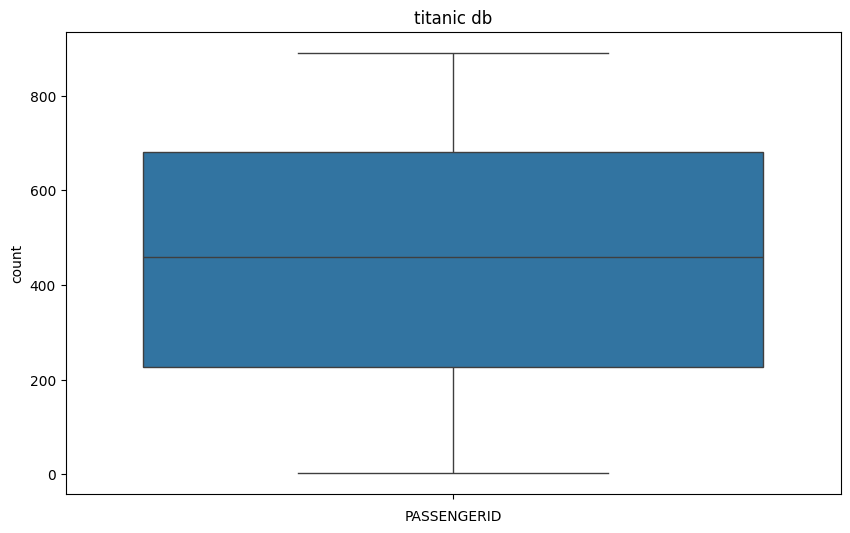

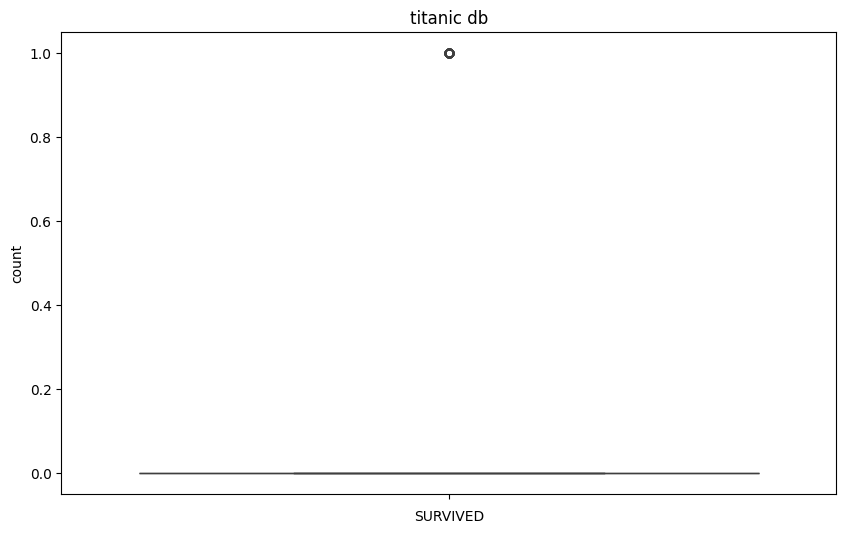

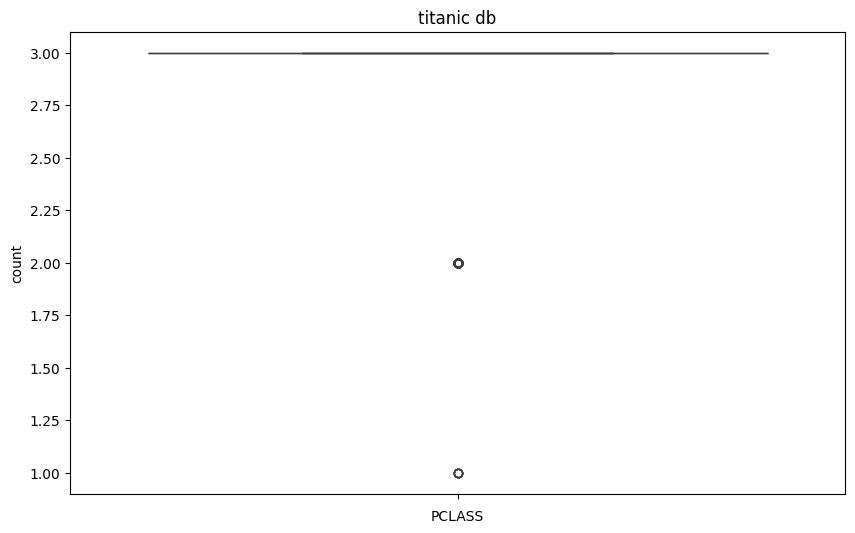

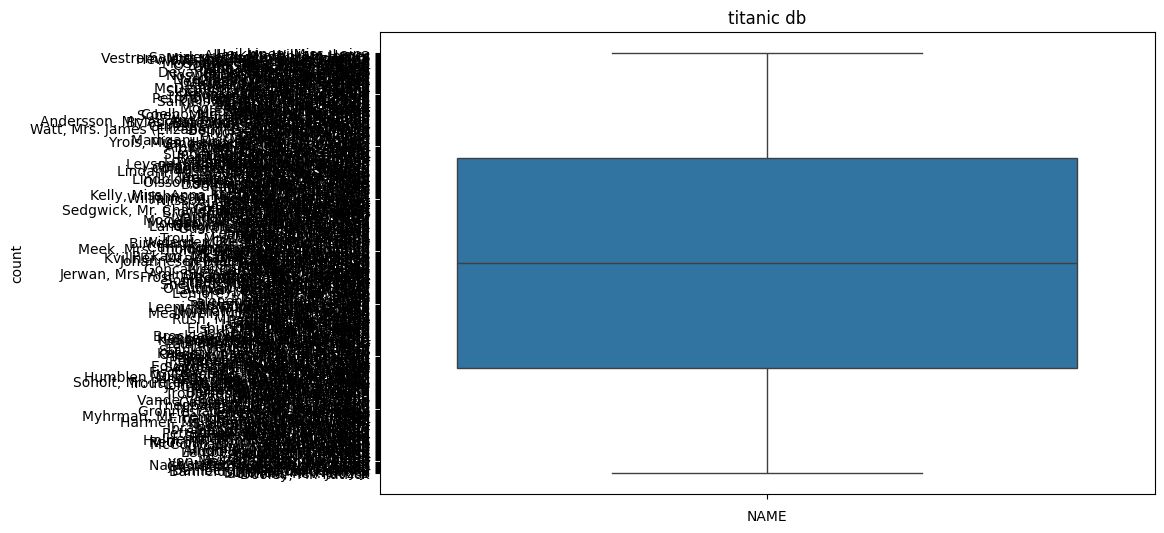

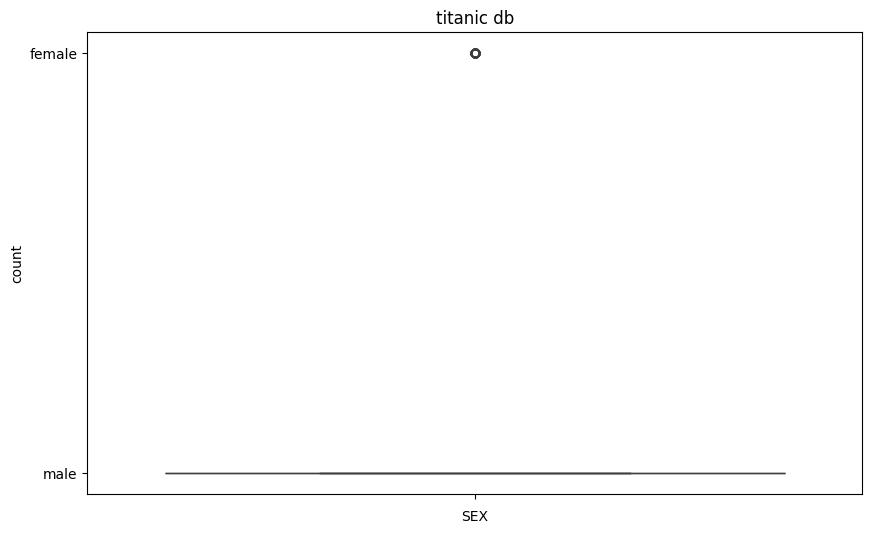

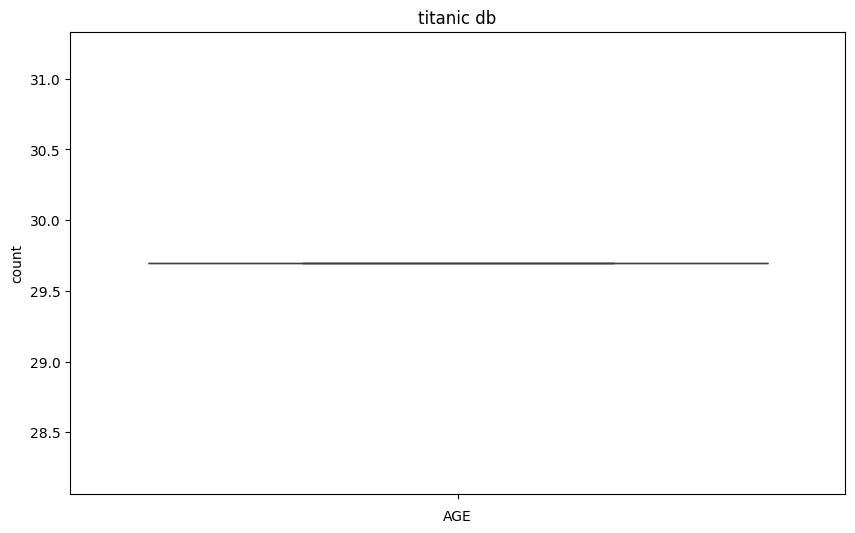

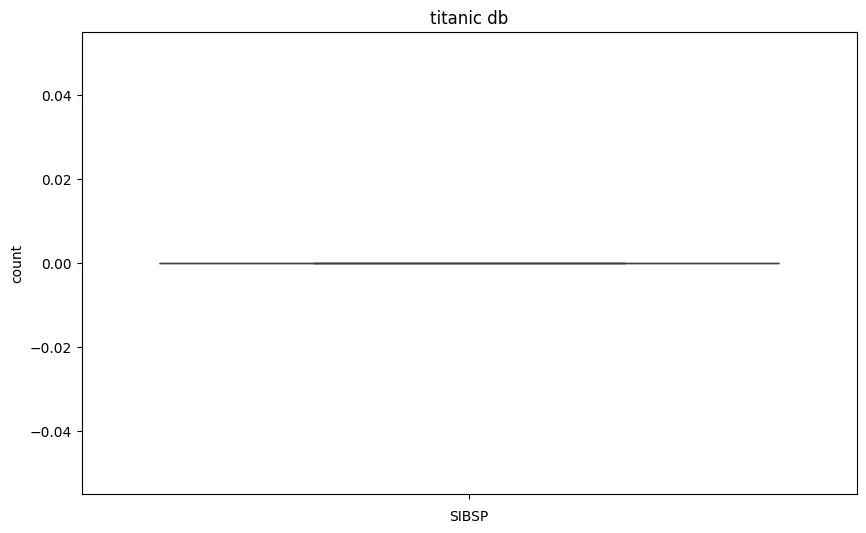

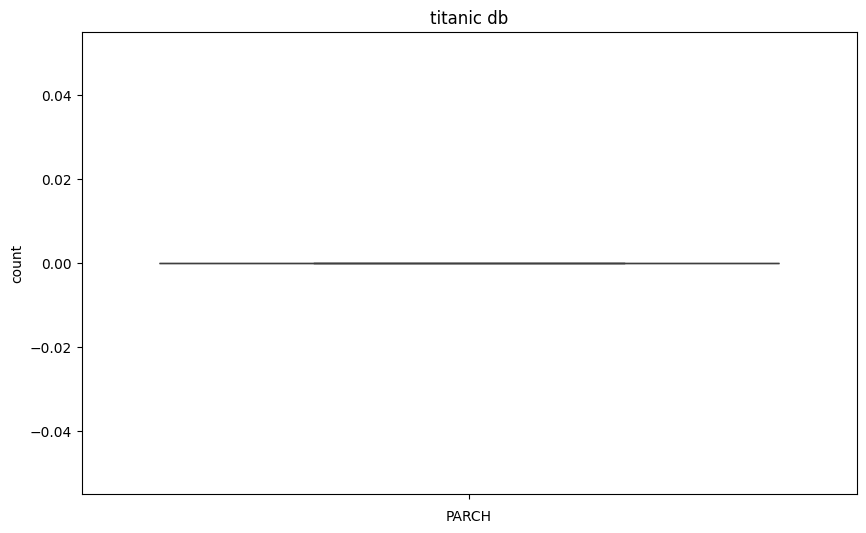

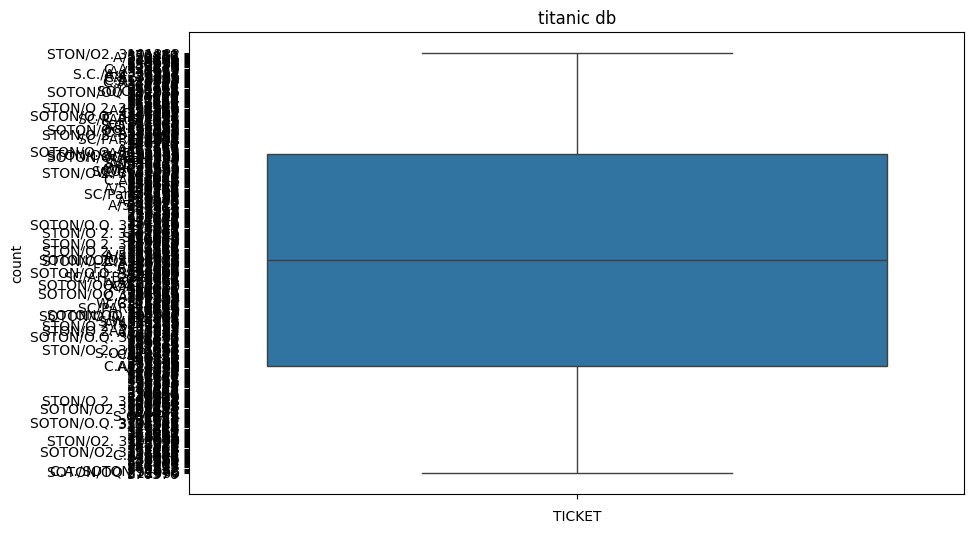

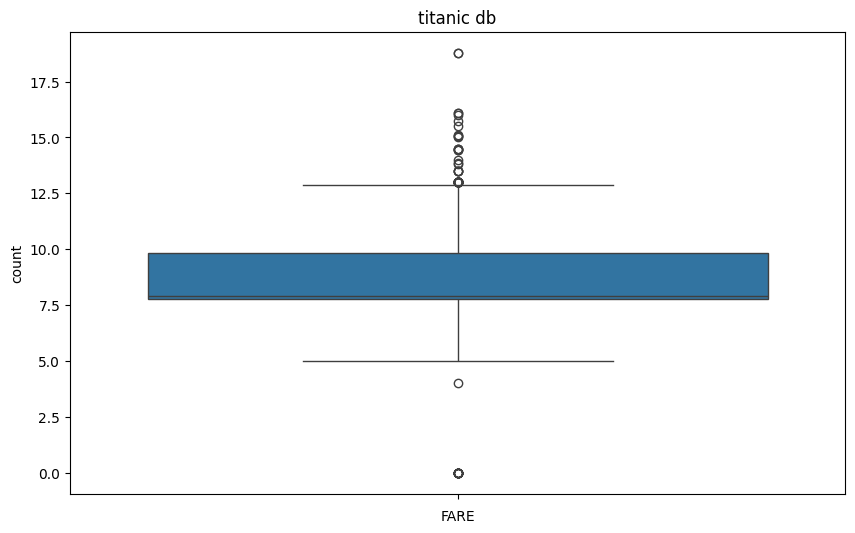

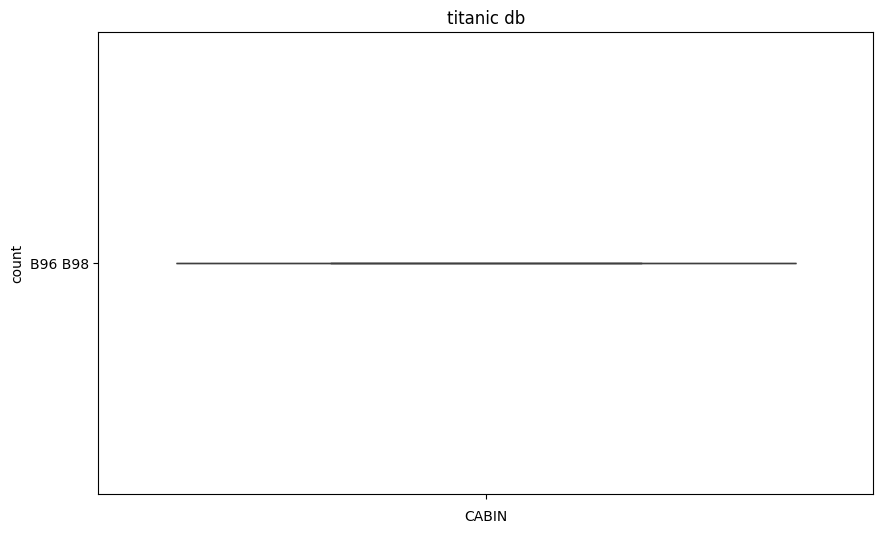

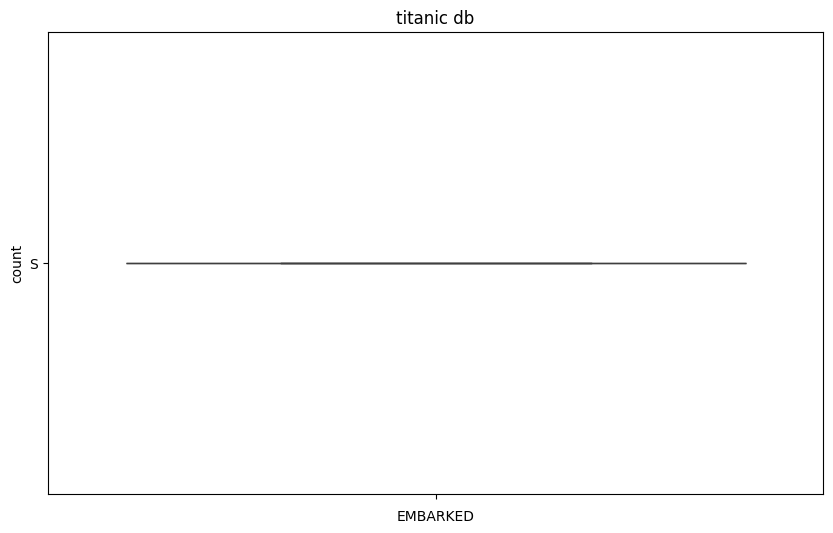

In [ ]:
for i in df.columns:
  if df[i].dtypes != "objects":
    plt.figure(figsize=(10,6))
    sns.boxplot(df[i])
    plt.title("titanic db")
    plt.xlabel(i)
    plt.ylabel("count")
    plt.show()

In [ ]:
from sklearn.preprocessing import  LabelEncoder
le=LabelEncoder()
for i in df.columns:
  if df[i].dtypes == "object":
    df[i]=le.fit_transform(df[i])



In [ ]:
df

,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,CABIN,EMBARKED
2,3,1,3,142,0,29.699118,0,0,392,7.9250,0,0
4,5,0,3,8,1,29.699118,0,0,278,8.0500,0,0
5,6,0,3,247,1,29.699118,0,0,122,8.4583,0,0
12,13,0,3,332,1,29.699118,0,0,324,8.0500,0,0
14,15,0,3,389,0,29.699118,0,0,237,7.8542,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
882,883,0,3,77,0,29.699118,0,0,299,10.5167,0,0
883,884,0,2,23,1,29.699118,0,0,344,10.5000,0,0
884,885,0,3,367,1,29.699118,0,0,376,7.0500,0,0
886,887,0,2,245,1,29.699118,0,0,11,13.0000,0,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=df
y=df["PCLASS"]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
re=RandomForestClassifier()
re.fit(x_train,y_train)
y_pred=re.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print("Accuracy Score",accuracy_score(y_pred,y_test)*100)

Accuracy Score 98.79518072289156


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print("Accuracy Score",accuracy_score(y_pred,y_test)*100)

Accuracy Score 80.72289156626506
